## Trabajo en Clase: Selección de Atributos y Reducción de Dimensionalidad - Automobile Dataset

NOTA: Este notebook tiene como predecesora a la notebook de Ingeniería de Atributos `Clase 09 FE autos.ipynb`.

**Dataset**: Utilizaremos el mismo **Automobile Dataset**, partiendo de la ingenieria de atributos de la práctica anterior, para luego aplicar técnicas que permitan reducir la complejidad del modelo y mitigar el sobreajuste (overfitting).

**Descripción del dataset**: https://www.kaggle.com/datasets/toramky/automobile-dataset/data

**URL del Dataset**: Desde el propio Kaggle o de [este link](https://drive.google.com/file/d/1WtYT7g0PJ287UwalVAbu5YBt4cA9eeiq/view?usp=drive_link)

### Instrucciones:

1. **Carga y Preparación de Datos**:
    - Realizar la limpieza básica: gestionar los valores `?`, eliminar registros con `price` nulo y convertir columnas categóricas ordinales (como `num-of-doors` o `num-of-cylinders`) a valores numéricos mapeados.
    - Imputar los valores faltantes en columnas numéricas usando la media.

2. **Fase de Explosión (Generación Masiva de Atributos)**:
    - Crear un dataset expandido (ej. `X_huge`) aplicando simultáneamente:
        - **One-Hot Encoding** para todas las variables categóricas.
        - **Columnas Matemáticas** (Relación peso-potencia, eficiencia, etc.).
        - **Transformaciones** (Logaritmo, Raíz Cuadrada, Z-Score, Ranking) sobre todas las variables numéricas base.
        - **Discretización (Binning)** por Cuartiles y por Entropía (usando árboles de decisión).
    - El objetivo es obtener un dataset con más de 150 variables.

3. **Evaluación de Overfitting**:
    - Definir una función para evaluar modelos que retorne el RMSE tanto de entrenamiento como de validación (usando `cross_validate` con `return_train_score=True`).
    - Entrenar un `DecisionTreeRegressor` (con poca poda para favorecer el sobreajuste) sobre el dataset original y sobre el dataset expandido.
    - Construir y analizar el **Overfitting Gap** (Val RMSE - Train RMSE).

4. **Técnicas de Filtro (Filter Methods)**:
    - Aplicar un **Filtro de Varianza** (`VarianceThreshold`) para eliminar variables con casi nula variabilidad.
    - Implementar un **Filtro de Alta Correlación**: identifica pares de variables con correlación superior a 0.9 y elimina una de ellas.
    - Utilizar **Selección Univariada** (`SelectKBest` con `f_regression`) para seleccionar las mejores 25 variables.

5. **Métodos Wrapper y Embedded**:
    - Implementar **Eliminación Recursiva de Atributos (`RFE`)** utilizando un árbol de decisión para seleccionar las mejores 25 variables.
    - Aplicar **Selección basada en Modelo** utilizando la clase `SelectFromModel` [[1]](https://scikit-learn.org/stable/modules/feature_selection.html#select-from-model) y pasarle un modelo **Lasso (L1)** con `alpha=0.1`.

6. **Reducción de Dimensionalidad (PCA)**:
    - Escalar los datos (StandardScaler).
    - Aplicar **Análisis de Componentes Principales (PCA)** para retener el 95% de la varianza.
    - Evaluar el desempeño del modelo usando los componentes principales.

7. **Comparativa y Conclusiones**:
    - Presentar una tabla comparativa final que incluya: Método, RMSE de Entrenamiento, RMSE de Validación, Cantidad de Atributos y el Overfitting Gap.
    - Responder: ¿Qué técnica logró el mejor equilibrio entre performance de validación y reducción de sobreajuste?

**Tips**:
- Al usar técnicas supervisadas de selección (como RFE o SelectKBest), asegúrarse de "pasarlas" por la validación cruzada para evitar el sesgo de selección.
- Observar cómo varia el Train RMSE a medida que se agregan variables potencialmente ruidosas y cómo las técnicas de FS intentan corregir el Val RMSE. ¿Siempre lo logran?
- ¿Que problemas tienen las técnicas como PCA si logran tener exito en la reducción de atributos?

**Resultado esperado**: Un reporte comparativo que demuestre empíricamente la necesidad de seleccionar atributos cuando se trabaja con datasets de alta dimensionalidad.


# 1. Carga y Preparación de Datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
from sklearn.feature_selection import VarianceThreshold

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Automobile_data.csv')
df.shape

(205, 26)

In [ ]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [ ]:
# Eliminamos registros donde price no está presente, ya que es nuestra variable objetivo
df_test = df[df["price"] == '?'].copy()
df = df[df["price"] != '?'].copy()

In [ ]:
# Transformemos los '?' en NaNs
df.replace('?', pd.NA, inplace=True)

# A las columnas que queramos imputar para despues, las pasamos a numericas y le imputamos cero
cols_numericas = [
    "normalized-losses",
    "horsepower",
    "price",
    "bore",
    "stroke",
    "peak-rpm",
]
df[cols_numericas] = df[cols_numericas].apply(pd.to_numeric, errors='coerce')
df['num-of-doors'] = df['num-of-doors'].map({'four': 4, 'two': 2, pd.NA: 4})
df['num-of-cylinders'] = df['num-of-cylinders'].map({
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12,
})

X_base = df.drop('price', axis=1)
y = df['price']

print(f"Dimensiones base: {X_base.shape}")

Dimensiones base: (201, 25)


# 2. Fase de Explosión (Generación Masiva de Atributos)

In [ ]:
def generate_all_features(X_in, y_in):
    X = X_in.copy()

    # 1. One-Hot Encoding de categóricas
    cat_cols = X.select_dtypes(include=['object', 'string']).columns
    X = pd.get_dummies(X, columns=cat_cols, prefix='ohe')

    # 2. Columnas Matemáticas Derivadas
    X['power_to_weight'] = X['horsepower'] / X['curb-weight']
    X['combined_mpg'] = (X['city-mpg'] + X['highway-mpg']) / 2
    X['vehicle_density'] = X['curb-weight'] / (X['length'] * X['width'] * X['height'])
    X['engine_efficiency'] = X['horsepower'] / X['engine-size']
    X['bore_stroke_ratio'] = X['bore'] / X['stroke']
    X['rpm_compression_idx'] = X['peak-rpm'] * X['compression-ratio']
    X['wheelbase_efficiency'] = X['wheel-base'] / X['highway-mpg']
    X['frontal_perimeter'] = (X['width'] + X['height']) / 2

    # 3. Normalizaciones y Transformaciones (sobre columnas numéricas base)
    num_cols_base = X_in.select_dtypes(include=[np.number]).columns

    for col in num_cols_base:
        if (X[col] > 0).all(): X[f'log_{col}'] = np.log(X[col])
        if (X[col] >= 0).all(): X[f'sqrt_{col}'] = np.sqrt(X[col])
        X[f'zscore_{col}'] = (X[col] - X[col].mean()) / X[col].std()
        X[f'rank_{col}'] = X[col].rank(method='min')

    # 4. Discretización (Binning)
    n_bins = 5
    for col in num_cols_base:
        try: X[f'bin_q_{col}'] = pd.qcut(X[col], q=n_bins, labels=False, duplicates='drop')
        except: pass
        tree = DecisionTreeRegressor(max_leaf_nodes=n_bins)
        tree.fit(X_in[[col]], y_in)
        X[f'bin_entropy_{col}'] = tree.apply(X_in[[col]])

    return X

X_huge = generate_all_features(X_base, y)
X_huge = X_huge.fillna(0)
print(f"Dimensiones del dataset expandido: {X_huge.shape}")

Dimensiones del dataset expandido: (201, 165)


# 3. Evaluación de Modelos

In [ ]:
def evaluate_model(X, y, name, estimator=DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=42)):
    scores = cross_validate(
        estimator,
        X, y, cv=3,
        scoring='neg_root_mean_squared_error',
        return_train_score=True,
    )
    train_rmse = -scores['train_score'].mean()
    val_rmse   = -scores['test_score'].mean()

    return {
        "Metodo": name,
        "Train RMSE": train_rmse,
        "Val RMSE": val_rmse,
        "Features": X.shape[1],
        "Overfitting Gap": val_rmse - train_rmse
    }

results_list = []

# 1. Base (Original Numeric)
X_base_numeric = X_base.select_dtypes(include=[np.number]).fillna(0)
results_list.append(evaluate_model(X_base_numeric, y, "Base (Original Numeric)"))

# 2. Huge DF (Dataset con explosión de atributos)
results_list.append(evaluate_model(X_huge, y, "Huge DF (175+ Features)"))

# 4. Técnicas de Filtro

In [ ]:
# 4.1. Filtro de Varianza
selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X_huge)
results_list.append(evaluate_model(X_var, y, "Variance Threshold"))

# 4.2. Filtro de Alta Correlación...


# 7. Comparación de Resultados

,Metodo,Train RMSE,Val RMSE,Features,Overfitting Gap
0,Base (Original Numeric),2842.249128,5181.655135,17,2339.406008
2,Variance Threshold,2510.715393,5298.367399,153,2787.652006
1,Huge DF (175+ Features),2500.364105,5452.503594,165,2952.139488


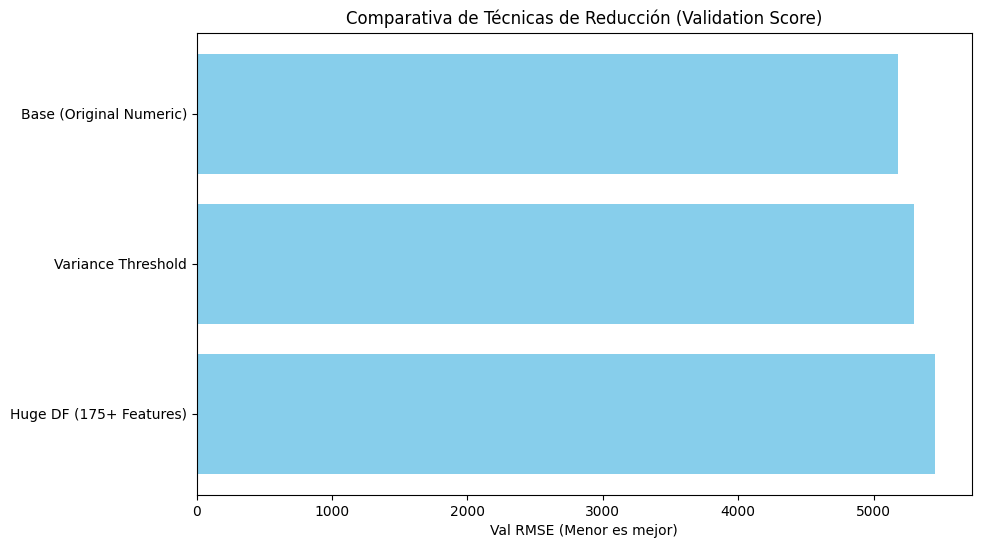

In [ ]:
df_results = pd.DataFrame(results_list).sort_values("Val RMSE")
display(df_results)

plt.figure(figsize=(10, 6))
plt.barh(df_results["Metodo"], df_results["Val RMSE"], color='skyblue')
plt.xlabel("Val RMSE (Menor es mejor)")
plt.title("Comparativa de Técnicas de Reducción (Validation Score)")
plt.gca().invert_yaxis()
plt.show()